# From Opinions to Probabilities

**Docker image**: `ml4t`

When multiple agents produce probability estimates, how do you combine them?
Simple averaging is a strong baseline, while extremization and calibration add
assumptions that must be validated. This notebook teaches **Neyman
extremization** and **Platt scaling** as conditional tools for combining
probability forecasts.

**Learning Objectives**:
- Understand why simple averaging underweights agreement
- Implement Neyman extremization with the diversity factor $d$
- Visualize how correlation between forecasters affects the aggregate
- Apply Platt scaling for post-hoc probability calibration

**Book Reference**: Chapter 24, Section 24.7 (Multi-Agent Forecasting Systems:
Aggregation)

**Prerequisites**: None; this is pure math, with no LLM calls.

In [1]:
"""From Opinions to Probabilities: aggregation math for multi-agent forecasting."""

import math
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from agent_pipeline import (
    brier_score,
    find_optimal_d,
    logodds_extremize,
    neyman_extremize,
    neyman_extremize_weighted,
    platt_scale,
)

from utils.reproducibility import set_global_seeds
from utils.style import COLORS, FIGSIZE, add_message_title, format_pct_axis, ml4t_palette

In [2]:
N_FORECASTERS = 3
SEED = 42

In [3]:
set_global_seeds(SEED)

## The Averaging Problem

Suppose three analysts each estimate a 65% probability that NVIDIA beats
earnings. Simple averaging gives 65%. Under an exchangeable correlation model,
Neyman extremization treats agreement among less-correlated forecasters as
additional information.

**Neyman extremization** formalizes that assumption: the aggregate
should be pushed away from the base rate (50%) proportional to a **diversity
factor** $d$:

$$d = \sqrt{\frac{n}{1 + (n-1)\rho}}$$

where $n$ is the number of forecasters and $\rho$ is their pairwise correlation.

$$p_{\text{extreme}} = p_{\text{base}} + d \cdot (\bar{p} - p_{\text{base}})$$

In [4]:
# Three forecasters at 65%, with varying correlation assumptions
probs = [0.65, 0.65, 0.65]

# Independent (rho=0): maximum diversity benefit
result_independent = neyman_extremize(probs, base=0.5, correlation=0.0)
print(
    f"Independent (ρ=0.0): d={result_independent.extremization_factor:.2f}, "
    f"p={result_independent.extremized_probability:.2f}"
)

# Moderately correlated (rho=0.3): typical for financial analysts
result_moderate = neyman_extremize(probs, base=0.5, correlation=0.3)
print(
    f"Moderate (ρ=0.3):    d={result_moderate.extremization_factor:.2f}, "
    f"p={result_moderate.extremized_probability:.2f}"
)

# Highly correlated (rho=0.7): analysts reading the same research
result_correlated = neyman_extremize(probs, base=0.5, correlation=0.7)
print(
    f"Correlated (ρ=0.7):  d={result_correlated.extremization_factor:.2f}, "
    f"p={result_correlated.extremized_probability:.2f}"
)

Independent (ρ=0.0): d=1.73, p=0.76
Moderate (ρ=0.3):    d=1.37, p=0.71
Correlated (ρ=0.7):  d=1.12, p=0.67


**Finding**: Under the stated correlation assumptions, lower correlation produces
stronger extremization. The result is conditional on $\rho$; the notebook does
not estimate forecaster dependence from data.

## Visualizing the Extremization Factor

How does $d$ change with the number of forecasters and their correlation?

In [5]:
correlations = [0.0, 0.1, 0.3, 0.5, 0.7]
n_range = list(range(2, 12))
curve_colors = ml4t_palette(len(correlations), categorical=True)
line_styles = ["-", "--", ":", "-.", "-"]
diversity_series = [
    (
        rho,
        [min(3.0, math.sqrt(n / (1 + (n - 1) * rho))) for n in n_range],
        color,
        line_style,
    )
    for rho, color, line_style in zip(correlations, curve_colors, line_styles, strict=True)
]

### Aggregate sensitivity

The second panel holds the mean forecast fixed and varies the correlation input.

In [6]:
mean_p = 0.65
base = 0.5
rho_range = np.linspace(0, 0.9, 50)
aggregate_series = []
for n, color, line_style in zip(
    [2, 3, 5, 8],
    ml4t_palette(4, categorical=True),
    line_styles[:4],
    strict=True,
):
    agg_probs = []
    for rho in rho_range:
        d_raw = math.sqrt(n / (1 + (n - 1) * rho)) if (1 + (n - 1) * rho) > 0 else 1.0
        d = max(1.0, min(3.0, d_raw))
        p_extreme = base + d * (mean_p - base)
        agg_probs.append(max(0.01, min(0.99, p_extreme)))
    aggregate_series.append((n, agg_probs, color, line_style))

### Combined sensitivity view

Both panels are constructed and displayed in one cell so the saved notebook
artifact contains the complete figure.

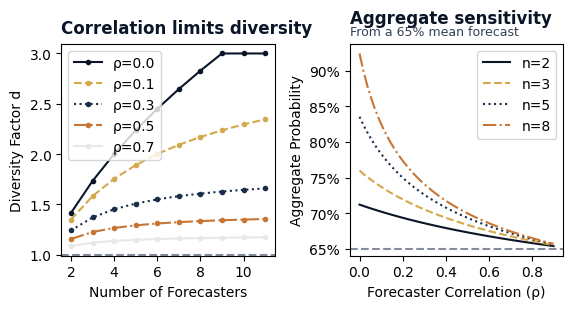

In [7]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE["dual_h_tall"])
for rho, values, color, line_style in diversity_series:
    axes[0].plot(
        n_range,
        values,
        marker="o",
        markersize=3,
        color=color,
        linestyle=line_style,
        label=f"ρ={rho}",
    )
axes[0].set(xlabel="Number of Forecasters", ylabel="Diversity Factor d")
add_message_title(axes[0], "Correlation limits diversity")
axes[0].legend()
axes[0].axhline(1.0, color=COLORS["neutral"], linestyle="--", alpha=0.6)

for n, values, color, line_style in aggregate_series:
    axes[1].plot(rho_range, values, color=color, linestyle=line_style, label=f"n={n}")
axes[1].set(xlabel="Forecaster Correlation (ρ)", ylabel="Aggregate Probability")
add_message_title(axes[1], "Aggregate sensitivity", subtitle="From a 65% mean forecast")
axes[1].legend()
axes[1].axhline(0.65, color=COLORS["neutral"], linestyle="--", alpha=0.6)
format_pct_axis(axes[1])
fig.tight_layout()
fig.show()

**Interpretation**: More forecasters increase $d$ with diminishing returns when
correlation is positive. These are sensitivity curves over an assumed common
correlation, not estimates of information added by real agents.

## Observed Dispersion Is Not in the Formula

This Neyman implementation uses the mean, panel size, and assumed correlation.
Two panels with the same mean receive the same aggregate even when their observed
dispersion differs.

In [8]:
# Same mean, different dispersion
divergent = [0.80, 0.65, 0.50]
result_divergent = neyman_extremize(divergent, base=0.5, correlation=0.3)

print(f"Specialist probabilities: {divergent}")
print(f"Simple mean: {sum(divergent) / len(divergent):.2f}")
print(
    f"Neyman (ρ=0.3): {result_divergent.extremized_probability:.2f} "
    f"(d={result_divergent.extremization_factor:.2f})"
)

# Compare: tight panel with the same mean
tight = [0.64, 0.65, 0.66]
result_tight = neyman_extremize(tight, base=0.5, correlation=0.3)

print(f"\nTight agreement: {tight}")
print(f"Simple mean: {sum(tight) / len(tight):.2f}")
print(f"Neyman (ρ=0.3): {result_tight.extremized_probability:.2f}")

Specialist probabilities: [0.8, 0.65, 0.5]
Simple mean: 0.65
Neyman (ρ=0.3): 0.71 (d=1.37)

Tight agreement: [0.64, 0.65, 0.66]
Simple mean: 0.65
Neyman (ρ=0.3): 0.71


**Finding**: Both panels produce the same aggregate because their means and assumed
correlations match. Observed dispersion must inform a separately estimated
dependence model or another aggregation rule; this formula does not infer it.

## Platt Scaling: Post-Hoc Calibration

**Platt scaling** adjusts probabilities based on observed calibration. The formula:

$$p' = \frac{d \cdot p^a}{d \cdot p^a + (1-p)^a}$$

- $a > 1$ pushes probabilities away from 0.5 (under-confident agents)
- $a < 1$ pulls probabilities toward 0.5 (over-confident agents)
- $d$ shifts the midpoint asymmetrically

This is algebraically equivalent to the chapter's logistic parameterization,
$p' = \sigma(a \cdot \text{logit}(p) + \log d)$; the two notations match
with $b = \log d$.

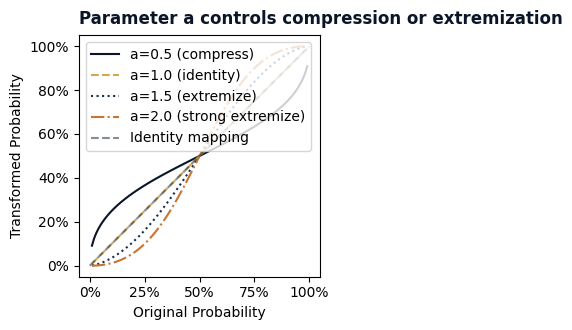

In [9]:
fig, ax = plt.subplots(figsize=FIGSIZE["single"])

p_range = np.linspace(0.01, 0.99, 100)

# Different a values
for (a, label), color, line_style in zip(
    [
        (0.5, "a=0.5 (compress)"),
        (1.0, "a=1.0 (identity)"),
        (1.5, "a=1.5 (extremize)"),
        (2.0, "a=2.0 (strong extremize)"),
    ],
    ml4t_palette(4, categorical=True),
    line_styles[:4],
    strict=True,
):
    calibrated = [platt_scale(p, a=a, d=1.0) for p in p_range]
    ax.plot(p_range, calibrated, color=color, linestyle=line_style, label=label)

ax.plot(
    [0, 1],
    [0, 1],
    color=COLORS["neutral"],
    linestyle="--",
    alpha=0.6,
    label="Identity mapping",
)
ax.set_xlabel("Original Probability")
ax.set_ylabel("Transformed Probability")
add_message_title(ax, "Parameter a controls compression or extremization")
ax.legend(loc="upper left")
ax.set_aspect("equal")
format_pct_axis(ax, axis="both")
fig.tight_layout()
fig.show()

**Interpretation**: Values above one extremize and values below one compress.
Whether either is appropriate must be learned from resolved training forecasts
and evaluated on disjoint data. A post-aggregation calibrator is valid when that
complete pipeline is fit and tested without reuse.

## Weighted Neyman Extremization

When a design supplies defensible forecast weights, **Weighted Neyman** uses the
Herfindahl index to compute a weight-only effective sample size:

$$\text{HI} = \sum w_i^2, \quad n_{\text{weight}} = \frac{1}{\text{HI}}$$

A uniform weighting gives $n_{\text{weight}} = n$. Concentrating weight on
one agent reduces it toward 1. The assumed common correlation then produces
$n_{\text{adjusted}} = n_{\text{weight}} /
[1 + (n_{\text{weight}} - 1)\rho]$, which drives extremization.

In [10]:
# Three agents with different illustrative weights
probs_w = [0.72, 0.58, 0.65]
weights_equal = [1.0, 1.0, 1.0]
weights_skewed = [0.8, 0.3, 0.5]

result_equal = neyman_extremize_weighted(probs_w, weights_equal, base=0.5, correlation=0.3)
result_skewed = neyman_extremize_weighted(probs_w, weights_skewed, base=0.5, correlation=0.3)
normalized_equal = np.array(weights_equal) / sum(weights_equal)
normalized_skewed = np.array(weights_skewed) / sum(weights_skewed)
weight_n_equal = 1 / float(np.square(normalized_equal).sum())
weight_n_skewed = 1 / float(np.square(normalized_skewed).sum())

pl.DataFrame(
    [
        {
            "weighting": "equal",
            "mean": result_equal.raw_probability,
            "extremized": result_equal.extremized_probability,
            "d": result_equal.extremization_factor,
            "weight_effective_n": weight_n_equal,
            "correlation_adjusted_n": result_equal.effective_n,
        },
        {
            "weighting": "skewed",
            "mean": result_skewed.raw_probability,
            "extremized": result_skewed.extremized_probability,
            "d": result_skewed.extremization_factor,
            "weight_effective_n": weight_n_skewed,
            "correlation_adjusted_n": result_skewed.effective_n,
        },
    ]
)

weighting,mean,extremized,d,weight_effective_n,correlation_adjusted_n
str,f64,f64,f64,f64,f64
"""equal""",0.65,0.7054,1.3693,3.0,1.88
"""skewed""",0.6719,0.7281,1.3269,2.612245,1.76


**Finding**: With skewed weights, the weighted mean shifts toward the most
heavily weighted agent (0.72). The weight-only effective size falls from 3.00
to 2.61; after the $\rho=0.3$ adjustment, the values are 1.88 and 1.76. The
adjusted value drives the smaller extremization push.

## Log-Odds Extremization

An alternative to Neyman: operate in **log-odds space** where the transformation
is naturally symmetric around 0.5:

$$p' = \sigma(a \cdot \text{logit}(p)), \quad \text{logit}(p) = \log\frac{p}{1-p}$$

This has the same effect as Platt scaling but is parameterized more intuitively:
$a > 1$ extremizes, $a < 1$ compresses.

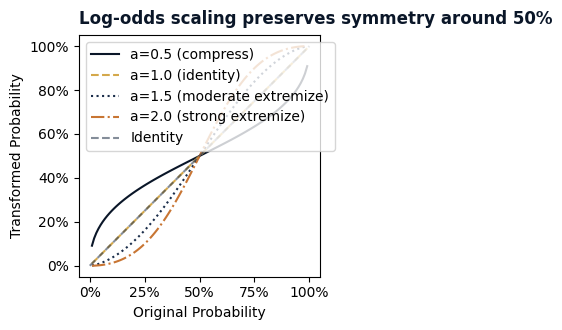

In [11]:
fig, ax = plt.subplots(figsize=FIGSIZE["single"])

p_range = np.linspace(0.01, 0.99, 100)

for (a, label), color, line_style in zip(
    [
        (0.5, "a=0.5 (compress)"),
        (1.0, "a=1.0 (identity)"),
        (1.5, "a=1.5 (moderate extremize)"),
        (2.0, "a=2.0 (strong extremize)"),
    ],
    ml4t_palette(4, categorical=True),
    line_styles[:4],
    strict=True,
):
    calibrated = [logodds_extremize(p, a) for p in p_range]
    ax.plot(p_range, calibrated, color=color, linestyle=line_style, label=label)

ax.plot([0, 1], [0, 1], color=COLORS["neutral"], linestyle="--", alpha=0.6, label="Identity")
ax.set_xlabel("Original Probability")
ax.set_ylabel("Transformed Probability")
add_message_title(ax, "Log-odds scaling preserves symmetry around 50%")
ax.legend(loc="upper left")
ax.set_aspect("equal")
format_pct_axis(ax, axis="both")
fig.tight_layout()
fig.show()

**Interpretation**: Log-odds extremization produces curves very similar to Platt
scaling but operates in a more interpretable space. The parameter $a$ directly
controls how aggressively probabilities move toward 0 or 1. The parameter must
be fit on resolved forecasts and evaluated out of sample.

## Finding the Optimal Calibration Parameter

Given resolved forecasts, we can fit $a$ on a training panel and evaluate the
frozen transformation on a disjoint test panel.

In [12]:
# Simulated resolved forecasts for a deterministic train/test demonstration
set_global_seeds(SEED)
n_questions = 240
train_size = 160
true_probs = np.random.beta(2, 2, n_questions)
outcomes = (np.random.random(n_questions) < true_probs).astype(float)
raw_forecasts = [0.5 + 0.6 * (p - 0.5) + np.random.normal(0, 0.05) for p in true_probs]
raw_forecasts = [max(0.05, min(0.95, p)) for p in raw_forecasts]

train_forecasts = raw_forecasts[:train_size]
train_outcomes = outcomes[:train_size]
test_forecasts = raw_forecasts[train_size:]
test_outcomes = outcomes[train_size:]

calibration_fit = find_optimal_d(train_forecasts, train_outcomes)
test_calibrated = [
    logodds_extremize(probability, calibration_fit.optimal_d) for probability in test_forecasts
]
test_brier_before = brier_score(test_forecasts, test_outcomes)
test_brier_after = brier_score(test_calibrated, test_outcomes)
test_improvement = (test_brier_before - test_brier_after) / test_brier_before

print(f"Train observations: {len(train_forecasts)}")
print(f"Test observations:  {len(test_forecasts)}")
print(f"Train-fitted a:     {calibration_fit.optimal_d:.3f}")
print(f"Test Brier before:  {test_brier_before:.4f}")
print(f"Test Brier after:   {test_brier_after:.4f}")
print(f"Test improvement:   {test_improvement:.1%}")

Train observations: 160
Test observations:  80
Train-fitted a:     1.150
Test Brier before:  0.1926
Test Brier after:   0.1883
Test improvement:   2.3%


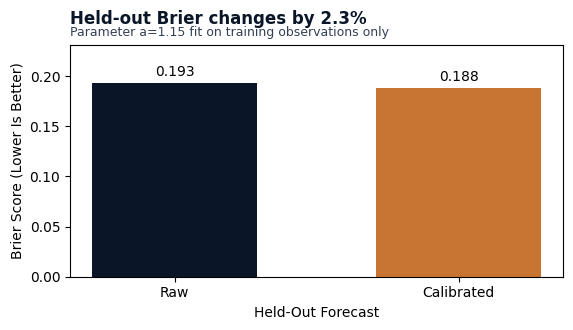

In [13]:
# Visualize the held-out comparison
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
test_briers = [test_brier_before, test_brier_after]
bars = ax.bar(
    ["Raw", "Calibrated"],
    test_briers,
    color=[COLORS["blue"], COLORS["copper"]],
    width=0.58,
)
ax.bar_label(bars, labels=[f"{value:.3f}" for value in test_briers], padding=3)
ax.set_xlabel("Held-Out Forecast")
ax.set_ylabel("Brier Score (Lower Is Better)")
ax.set_ylim(0, max(test_briers) * 1.2)
add_message_title(
    ax,
    f"Held-out Brier changes by {test_improvement:.1%}",
    subtitle=f"Parameter a={calibration_fit.optimal_d:.2f} fit on training observations only",
)
fig.tight_layout()
fig.show()

**Finding**: The coefficient is selected using training observations only, and
the displayed Brier comparison comes only from the held-out panel. This small
synthetic example demonstrates evaluation mechanics, not a deployable estimate
of future calibration benefit.

## Sensitivity Analysis: How Many Agents Do You Need?

A practical question: given a budget for LLM calls, how many specialist agents
should you run?

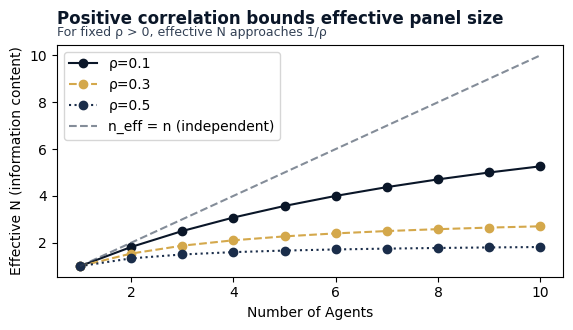

In [14]:
fig, ax = plt.subplots(figsize=FIGSIZE["single"])

# Fixed per-agent probability, varying n and rho
for rho, color, line_style in zip(
    [0.1, 0.3, 0.5],
    ml4t_palette(3, categorical=True),
    line_styles[:3],
    strict=True,
):
    effective_n = []
    agent_counts = list(range(1, 11))
    for n in agent_counts:
        denom = 1 + (n - 1) * rho
        d = math.sqrt(n / denom) if denom > 0 else 1.0
        effective_n.append(d**2)

    ax.plot(
        agent_counts,
        effective_n,
        marker="o",
        color=color,
        linestyle=line_style,
        label=f"ρ={rho}",
    )

ax.plot(
    agent_counts,
    agent_counts,
    color=COLORS["neutral"],
    linestyle="--",
    alpha=0.6,
    label="n_eff = n (independent)",
)
ax.set_xlabel("Number of Agents")
ax.set_ylabel("Effective N (information content)")
add_message_title(
    ax,
    "Positive correlation bounds effective panel size",
    subtitle=r"For fixed ρ > 0, effective N approaches 1/ρ",
)
ax.legend()
fig.tight_layout()
fig.show()

**Finding**: For fixed positive $\rho$, effective $N$ approaches $1/\rho$ as
the panel grows. At $\rho=0.3$, the limit is about 3.33 and the ten-agent panel
reaches 2.70. These are analytical consequences of the assumed correlation.

## Key Takeaways

1. **Simple averaging is the baseline**: Extremization must improve on it out of sample
2. **Neyman extremization** formalizes a conditional information model via the
   diversity factor $d = \sqrt{n / (1 + (n-1)\rho)}$
3. **Weighted Neyman** accounts for heterogeneous confidence via the Herfindahl
   index, preventing over-extremization when one agent dominates
4. **Observed dispersion is separate**: This formula uses assumed correlation,
   not the realized spread of panel forecasts
5. **Effective N is bounded**: For fixed $\rho > 0$, it approaches $1/\rho$
6. **Calibration needs separation**: Fit transformations on resolved training
   forecasts and evaluate them on held-out observations

**Next**: [`06_multi_agent_research`](06_multi_agent_research.ipynb), which tests
whether running multiple identical research agents on the same question
actually produces diversity worth aggregating, or whether the panel
collapses to a single mode.

**Book**: Section 24.7 covers aggregation theory, including connections to
Condorcet's jury theorem and prediction market design.